# Interactive Robot Kinematics and Trajectory Generation

Welcome\! This notebook is designed to help you understand the core principles of robot kinematics and motion planning for a simple 2-link planar robot.

**Key Concepts Covered:**

1.  **Direct Geometric Model (DGM) / Forward Kinematics (FK):** Calculating the end-effector's Cartesian position from known joint angles.
2.  **Inverse Geometric Model (IGM) / Inverse Kinematics (IK):** Calculating the required joint angles to reach a desired Cartesian position. We'll explore workspace limits and multiple solutions ("elbow up/down").
3.  **Trajectory Generation:** Planning a smooth, controlled motion between two points. We'll implement two fundamental types:
      * **Linear Trajectory:** The end-effector moves in a perfect straight line.
      * **Joint Trajectory:** Each joint moves synchronously to the target configuration.
4.  **Trapezoidal Velocity Profiles:** A common method for ensuring smooth acceleration and deceleration, preventing jerky movements.

You can interact with the controls at the bottom to define a target position and see how the robot and its joints behave. Pay close attention to the graphs\!

-----

In [1]:
# Import necessary libraries
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
from IPython.display import display, clear_output, HTML
import base64
%matplotlib inline

In [ ]:
# --- Robot Definition ---
# Length of the robot links in meters
L1 = 1.0
L2 = 0.8

# --- Simulation Parameters ---
# Maximum velocity and acceleration for the trapezoidal profiles
# Cartesian motion parameters
V_MAX_CARTESIAN = 0.5  # m/s
A_MAX_CARTESIAN = 1.0  # m/s^2
# Joint motion parameters
V_MAX_JOINT = np.deg2rad(90)  # rad/s
A_MAX_JOINT = np.deg2rad(180) # rad/s^2

# Time step for the simulation
DT = 0.02  # seconds

In [3]:
def forward_kinematics(theta1, theta2, l1, l2):
    """
    Calculates the end-effector and joint positions.
    Input:
        theta1, theta2: Joint angles in radians.
        l1, l2: Link lengths.
    Output:
        (x_p1, y_p1): Position of the elbow joint.
        (x_p2, y_p2): Position of the end-effector.
        (All positions are 3D with z=0 for future compatibility)
    """
    x_p1 = l1 * np.cos(theta1)
    y_p1 = l1 * np.sin(theta1)
    
    x_p2 = x_p1 + l2 * np.cos(theta1 + theta2)
    y_p2 = y_p1 + l2 * np.sin(theta1 + theta2)
    
    return (x_p1, y_p1, 0.0), (x_p2, y_p2, 0.0)

def inverse_kinematics(x, y, l1, l2):
    """
    Calculates the joint angles for a given end-effector position.
    Input:
        x, y: Target Cartesian coordinates.
        l1, l2: Link lengths.
    Output:
        A dictionary with 'up' and 'down' solutions, each being (theta1, theta2).
        Returns None if the point is out of reach.
    """
    dist_sq = x**2 + y**2
    
    # Check if the target is reachable
    if dist_sq > (l1 + l2)**2 or dist_sq < (l1 - l2)**2:
        raise ValueError(f"Target ({x:.2f}, {y:.2f}) is outside the robot's workspace!")

    # Cosine rule to find theta2
    cos_theta2 = (dist_sq - l1**2 - l2**2) / (2 * l1 * l2)
    
    # Elbow down solution
    theta2_down = np.arccos(cos_theta2)
    theta1_down = np.arctan2(y, x) - np.arctan2(l2 * np.sin(theta2_down), l1 + l2 * np.cos(theta2_down))
    
    # Elbow up solution
    theta2_up = -np.arccos(cos_theta2)
    theta1_up = np.arctan2(y, x) - np.arctan2(l2 * np.sin(theta2_up), l1 + l2 * np.cos(theta2_up))
    
    return {
        'down': (theta1_down, theta2_down),
        'up': (theta1_up, theta2_up)
    }

In [4]:
def trapezoidal_profile(distance, v_max, a_max, dt):
    """
    Generates a trapezoidal velocity profile for a given distance.
    Returns arrays for time, position, velocity, and acceleration.
    """
    # Check if the move is even possible given v_max and a_max
    if v_max**2 / a_max > distance:
        # Triangular profile (doesn't reach v_max)
        t_accel = np.sqrt(distance / a_max)
        t_total = 2 * t_accel
        v_peak = a_max * t_accel
        t_cruise = 0
    else:
        # Trapezoidal profile
        t_accel = v_max / a_max
        dist_accel = 0.5 * a_max * t_accel**2
        dist_cruise = distance - 2 * dist_accel
        t_cruise = dist_cruise / v_max
        t_total = 2 * t_accel + t_cruise
        v_peak = v_max

    time_pts = np.arange(0, t_total, dt)
    pos = np.zeros_like(time_pts)
    vel = np.zeros_like(time_pts)
    acc = np.zeros_like(time_pts)

    for i, t in enumerate(time_pts):
        if t < t_accel:
            # Acceleration phase
            acc[i] = a_max
            vel[i] = a_max * t
            pos[i] = 0.5 * a_max * t**2
        elif t < t_accel + t_cruise:
            # Constant velocity phase
            acc[i] = 0
            vel[i] = v_peak
            pos[i] = 0.5 * a_max * t_accel**2 + v_peak * (t - t_accel)
        else:
            # Deceleration phase
            t_decel = t - t_accel - t_cruise
            acc[i] = -a_max
            vel[i] = v_peak - a_max * t_decel
            pos[i] = distance - 0.5 * a_max * (t_total - t)**2
            
    # Ensure final position is exact
    if len(pos) > 0:
        pos[-1] = distance
        
    return time_pts, pos, vel, acc

In [5]:
def generate_linear_trajectory(p_start, p_end, l1, l2, v_max, a_max, dt, ik_mode='auto'):
    """Generates a trajectory for a straight-line Cartesian move."""
    # 1. Define Path in Cartesian Space
    p_start_np = np.array(p_start[:2])
    p_end_np = np.array(p_end[:2])
    path_vector = p_end_np - p_start_np
    total_dist = np.linalg.norm(path_vector)

    if total_dist < 1e-6:
        return np.array([]), np.array([]), np.array([]), np.array([])
    
    path_direction = path_vector / total_dist

    # 2. Apply Trapezoidal Profile to the Cartesian path length
    time, s, s_dot, s_ddot = trapezoidal_profile(total_dist, v_max, a_max, dt)

    # 3. Discretize and Solve using IGM
    q_path = []
    
    # Get starting configuration
    try:
        q_start_sol = inverse_kinematics(p_start[0], p_start[1], l1, l2)
    except ValueError as e:
        raise e

    # Determine initial IK configuration based on mode
    if ik_mode == 'auto':
        # In a real scenario, you'd check against the robot's current position.
        # Here we just default to 'down' for the start of the auto move.
        q_prev = q_start_sol['down']
    else:
        q_prev = q_start_sol[ik_mode]
    
    q_path.append(q_prev)

    for i in range(1, len(time)):
        # Calculate the desired Cartesian position at this time step
        p_current = p_start_np + s[i] * path_direction
        
        try:
            q_solutions = inverse_kinematics(p_current[0], p_current[1], l1, l2)
        except ValueError as e:
            raise e
        
        # Choose the IK solution
        if ik_mode == 'auto':
            # Choose the solution with the smallest joint change (Euclidean distance)
            dist_down = np.linalg.norm(np.array(q_solutions['down']) - np.array(q_prev))
            dist_up = np.linalg.norm(np.array(q_solutions['up']) - np.array(q_prev))
            q_current = q_solutions['down'] if dist_down <= dist_up else q_solutions['up']
        else:
            q_current = q_solutions[ik_mode]
            
        q_path.append(q_current)
        q_prev = q_current
        
    q_path = np.array(q_path)

    # 4. Calculate Joint Profiles by numerical differentiation
    q_dot_path = np.diff(q_path, axis=0, prepend=[q_path[0]]) / dt
    q_ddot_path = np.diff(q_dot_path, axis=0, prepend=[q_dot_path[0]]) / dt
    
    return time, q_path, q_dot_path, q_ddot_path

def generate_joint_trajectory(q_start, q_end, v_max, a_max, dt):
    """Generates a synchronized trajectory for a joint-space move using
    per-joint trapezoidal (or triangular) profiles that are stretched/squeezed
    so every joint motion takes the same total time (synchronization).
    Inputs:
      q_start, q_end : iterable of joint positions (radians)
      v_max, a_max   : peak joint velocity and acceleration (rad/s, rad/s^2)
      dt             : time step (s)
    Returns:
      time, q_path, q_dot_path, q_ddot_path
    """
    q_start = np.array(q_start, dtype=float)
    q_end = np.array(q_end, dtype=float)
    delta_q = np.abs(q_end - q_start)
    signs = np.sign(q_end - q_start)

    # 1) compute minimal time for each joint with given v_max, a_max
    min_times = []
    for d in delta_q:
        if d <= 0:
            min_times.append(0.0)
            continue
        if v_max**2 / a_max > d:  # triangular
            t = 2.0 * np.sqrt(d / a_max)
        else:  # trapezoidal
            t = d / v_max + v_max / a_max
        min_times.append(t)
    t_total = max(min_times)

    if t_total < dt or t_total == 0.0:
        # nothing to do or too short
        return np.array([]), np.array([]), np.array([]), np.array([])

    time = np.arange(0.0, t_total + dt/2, dt)  # include last point
    q_path = np.zeros((len(time), len(q_start)))
    q_vel = np.zeros_like(q_path)
    q_acc = np.zeros_like(q_path)

    # helper: compute v_peak that yields distance d in total time T with accel a
    for i, d in enumerate(delta_q):
        if d == 0.0:
            q_path[:, i] = q_start[i]
            continue

        # Solve v_peak from: d = v_peak*T - v_peak^2 / a  => v^2 - a*T*v + a*d = 0
        a = a_max
        T = t_total
        discr = (a * T)**2 - 4.0 * a * d
        if discr < 0:
            # numeric safety: fall back to using v_max (shouldn't normally happen)
            v_peak = v_max
        else:
            v_peak_candidate = (a * T - np.sqrt(discr)) / 2.0  # choose smaller root (ensures non-negative cruise)
            # clamp to v_max
            v_peak = min(v_peak_candidate, v_max)

        # if v_peak is effectively zero (very small distance), make triangular small profile
        if v_peak <= 1e-12:
            t_acc = T / 2.0
            v_peak = a * t_acc
            t_cruise = 0.0
        else:
            t_acc = v_peak / a
            t_cruise = T - 2.0 * t_acc
            if t_cruise < 0:  # numerical correction -> triangular
                t_acc = T / 2.0
                v_peak = a * t_acc
                t_cruise = 0.0

        dist_acc = 0.5 * a * t_acc**2
        # build profiles
        pos = np.zeros(len(time))
        vel = np.zeros(len(time))
        acc = np.zeros(len(time))

        for j, t in enumerate(time):
            if t < t_acc:
                acc[j] = a
                vel[j] = a * t
                pos[j] = 0.5 * a * t**2
            elif t < t_acc + t_cruise:
                acc[j] = 0.0
                vel[j] = v_peak
                pos[j] = dist_acc + v_peak * (t - t_acc)
            else:
                # deceleration
                t_decel = t - t_acc - t_cruise
                acc[j] = -a
                vel[j] = v_peak - a * t_decel
                # use symmetric formulation to avoid small final errors
                pos[j] = d - 0.5 * a * (T - t)**2

        # apply sign and offset
        q_path[:, i] = q_start[i] + signs[i] * pos
        q_vel[:, i] = signs[i] * vel
        q_acc[:, i] = signs[i] * acc

    # numerical differentiation to provide q_dot and q_ddot (but we already have vel/acc)
    # prefer the generated continuous vel/acc but provide consistent shapes
    q_dot_path = q_vel
    q_ddot_path = q_acc

    return time, q_path, q_dot_path, q_ddot_path

Generating animation... This may take a moment.



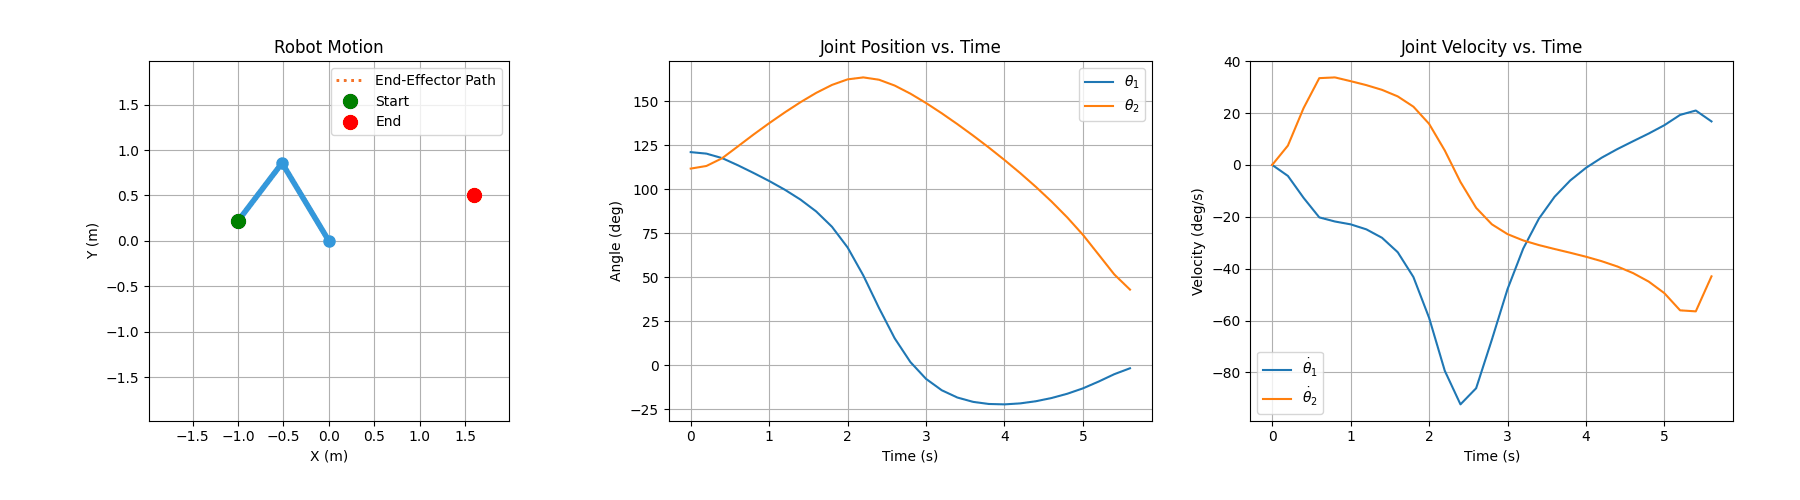

In [19]:
# ---          Parameters              ---
# ----------------------------------------

# Starting position for the robot's end-effector
START_X = -1.0
START_Y = 0.22

# Goal position for the robot's end-effector
TARGET_X = 1.6
TARGET_Y = 0.5

# Type of motion to perform
# Options: 'L' for Linear Path or 'J' for Joint Move
MOVE_TYPE = 'L'

# Inverse Kinematics (IK) solution to use
# Options: 'up', 'down'
# for linear moves, the starting configuration is used for the complete move
IK_SOLUTION_START = 'down'
IK_SOLUTION_END = 'down'
# ----------------------------------------


# --- 1. Generate the Trajectory Data ---
# We wrap this in a try/except block to catch workspace errors gracefully.
try:
    
    p_end = np.array([TARGET_X, TARGET_Y, 0.0])

    # Generate the trajectory based on the selected move type
    if MOVE_TYPE == 'L':
        # compute the fixed starting configuration (q_start)
        q_start = inverse_kinematics(START_X, START_Y, L1, L2)[IK_SOLUTION_START]
        _, p_start_tuple = forward_kinematics(q_start[0], q_start[1], L1, L2)
        p_start = np.array(p_start_tuple)
        time, q_path, q_dot_path, q_ddot_path = generate_linear_trajectory(
            p_start, p_end, L1, L2,
            V_MAX_CARTESIAN, A_MAX_CARTESIAN, DT,
            IK_SOLUTION_START
        )
        trajectory_type_for_trace = 'linear'
    elif MOVE_TYPE == 'J':
        # compute the fixed starting configuration (q_start)
        q_start = inverse_kinematics(START_X, START_Y, L1, L2)[IK_SOLUTION_START]
        _, p_start_tuple = forward_kinematics(q_start[0], q_start[1], L1, L2)
        p_start = np.array(p_start_tuple)
        q_end = inverse_kinematics(p_end[0], p_end[1], L1, L2)[IK_SOLUTION_END]
        
        time, q_path, q_dot_path, q_ddot_path = generate_joint_trajectory(
            q_start, q_end,
            V_MAX_JOINT, A_MAX_JOINT, DT
        )
        trajectory_type_for_trace = 'joint'
    else:
        raise ValueError(f"Unknown MOVE_TYPE: '{MOVE_TYPE}'. Please choose 'L' or 'J'.")

    # --- 2. Setup the Plots ---
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    ax_anim, ax_pos, ax_vel = axes.flatten()
    fig.tight_layout(pad=4.0)

    # Configure Robot Animation Plot
    ax_anim.set_aspect('equal', 'box')
    workspace_radius = L1 + L2
    ax_anim.set_xlim(-workspace_radius * 1.1, workspace_radius * 1.1)
    ax_anim.set_ylim(-workspace_radius * 1.1, workspace_radius * 1.1)
    ax_anim.set_title("Robot Motion")
    ax_anim.set_xlabel("X (m)")
    ax_anim.set_ylabel("Y (m)")
    ax_anim.grid(True)
    
    # Configure Joint Position Plot
    ax_pos.set_title("Joint Position vs. Time")
    ax_pos.set_xlabel("Time (s)")
    ax_pos.set_ylabel("Angle (deg)")
    ax_pos.grid(True)

    # Configure Joint Velocity Plot
    ax_vel.set_title("Joint Velocity vs. Time")
    ax_vel.set_xlabel("Time (s)")
    ax_vel.set_ylabel("Velocity (deg/s)")
    ax_vel.grid(True)
    
    # --- 3. Plot the complete trajectory graphs ---
    # Since we have all the data, we can plot the graphs before the animation starts.
    ax_pos.plot(time, np.rad2deg(q_path[:, 0]), label=r'$\theta_1$')
    ax_pos.plot(time, np.rad2deg(q_path[:, 1]), label=r'$\theta_2$')
    ax_pos.legend()
    
    ax_vel.plot(time, np.rad2deg(q_dot_path[:, 0]), label=r'$\dot{\theta}_1$')
    ax_vel.plot(time, np.rad2deg(q_dot_path[:, 1]), label=r'$\dot{\theta}_2$')
    ax_vel.legend()

    # --- 4. Prepare Animation Elements ---
    line_robot, = ax_anim.plot([], [], 'o-', lw=4, markersize=8, color='#3498db')
    trace_path, = ax_anim.plot([], [], ':', lw=2, color='#e74c3c', label='End-Effector Path')
    point_start_plot = ax_anim.plot(p_start[0], p_start[1], 'go', markersize=10, label='Start')
    point_end_plot = ax_anim.plot(p_end[0], p_end[1], 'ro', markersize=10, label='End')
    ax_anim.legend()

    # Calculate all end-effector points for the trace
    ee_points = [forward_kinematics(q[0], q[1], L1, L2)[1] for q in q_path]
    ee_x_path = [p[0] for p in ee_points]
    ee_y_path = [p[1] for p in ee_points]
    
    # Initialization function for the animation
    def init():
        line_robot.set_data([], [])
        trace_path.set_data([], [])
        return line_robot, trace_path

    # Update function called for each frame of the animation
    def update(frame):
        # Update robot arm position
        p1, p2 = forward_kinematics(q_path[frame][0], q_path[frame][1], L1, L2)
        line_robot.set_data([0, p1[0], p2[0]], [0, p1[1], p2[1]])
        
        # Update the end-effector trace
        trace_path.set_data(ee_x_path[:frame+1], ee_y_path[:frame+1])
        return line_robot, trace_path

    # --- 5. Create and Display the Animation ---
    # Create the animation object
    ani = FuncAnimation(fig, update, frames=len(q_path),
                        init_func=init, blit=True, interval=DT*1000)

    # Save the animation as a GIF file using the Pillow writer.

    print("Generating animation... This may take a moment.")
    gif_path = "robot_animation.gif"
    ani.save(gif_path, writer='pillow', fps=int(1/DT))
        
    # Close the static plot to avoid a duplicate image appearing.
    plt.close(fig)

    # Display the generated GIF.
    # Read the generated GIF file in binary mode
    with open(gif_path, "rb") as f:
        # Encode the binary data into a Base64 string
        b64_string = base64.b64encode(f.read()).decode("utf-8")

    # Create an HTML img tag with the embedded Base64 data
    html_tag = f'<img src="data:image/gif;base64,{b64_string}">'
    
    # Display the final animation
    display(HTML(html_tag))

except ValueError as e:
    print(f"🛑 ERROR: Could not generate trajectory.")
    print(f"   Reason: {e}")